# Capstone Project 2 - Credit Card Fraud Prediction. 

In [1]:
# Importing the required libraries. 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from imblearn.over_sampling import SMOTE # To handle imbalanced datasets.

In [2]:
# Importing the dataset. 
ccfp = pd.read_csv(r"D:\AI_ML_DS Course_IIT Guwahati (Sept 2025-June 2026)\Capstone Projects\01_ML Project\04_Capstone Project 2 - Credit Card Fraud Prediction\creditcard.csv")
ccfp

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0


In [3]:
# Checking the first 5 rows of the dataset. 
ccfp.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
# Checking the last 5 rows of the dataset. 
ccfp.tail()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0


In [5]:
# Checking the shape of the dataset. 
ccfp.shape

(284807, 31)

In [6]:
# Checking the size of the dataset.
ccfp.size

8829017

In [7]:
# Checking the overview of the dataset.
ccfp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [8]:
# Checking the descriptive statistics for all the "numeric" columns in the dataset.
ccfp.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,284807.000000,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,0.000017,0.000008,0.014970,0.000023,0.000022,-0.000016,0.000029,0.000003,0.004311,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958679,1.651295,8.073856,1.415859,1.380234,1.332244,1.237076,1.194354,2.538010,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-56.407510,-72.715728,-48.325589,-5.683171,-113.743307,-26.160506,-43.557242,-73.216718,-13.434066,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-0.920327,-0.598532,-0.890365,-0.848611,-0.691568,-0.768290,-0.554011,-0.208630,-0.643068,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,0.018027,0.065467,0.179832,-0.019816,-0.054314,-0.274159,0.040104,0.022358,-0.051331,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315632,0.803724,1.027212,0.743355,0.611926,0.398487,0.570450,0.327349,0.597139,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930,22.057729,4232.000000,16.875344,34.801666,73.301626,120.589494,20.007208,1221.000000,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [9]:
# Checking for the NaN values in each column of the dataset.
ccfp.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [10]:
# Checking for the unique values in each column of the dataset.
ccfp.nunique()

Time      124592
V1        275643
V2        275653
V3        275655
V4        275650
V5        275650
V6        275632
V7        275647
V8        275643
V9        275639
V10       275644
V11       275647
V12       275648
V13       275655
V14       275652
V15       275639
V16       275645
V17       275646
V18       275655
V19       275645
V20       275632
V21       275617
V22       275644
V23       275611
V24       275645
V25       275640
V26       275647
V27       275597
V28       275558
Amount     32767
Class          2
dtype: int64

In [11]:
# Checking for the duplicate rows in the dataset.
ccfp.duplicated().sum()

np.int64(1081)

In [12]:
# Dropping the duplicate rows from the dataset.
ccfp.drop_duplicates(subset = None, keep = "first", inplace = True)

In [13]:
# Checking for the column names of each column in the dataset.
ccfp.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

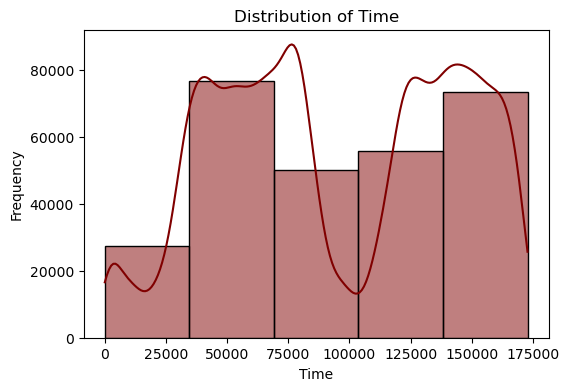

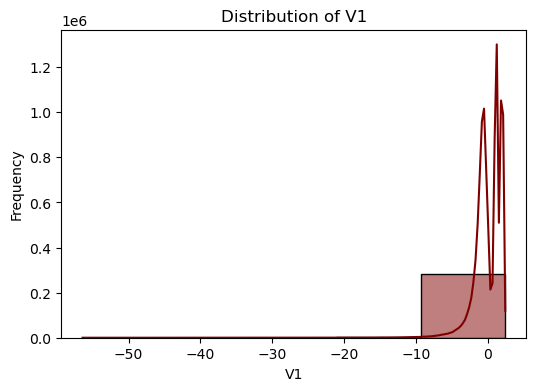

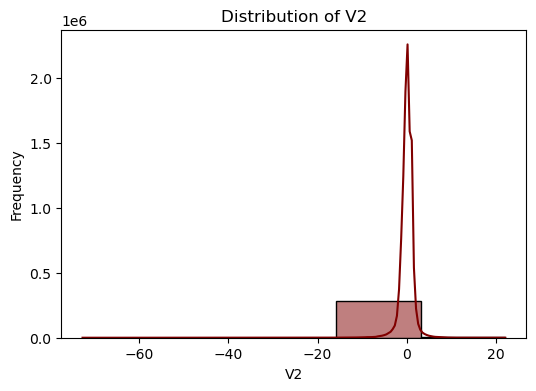

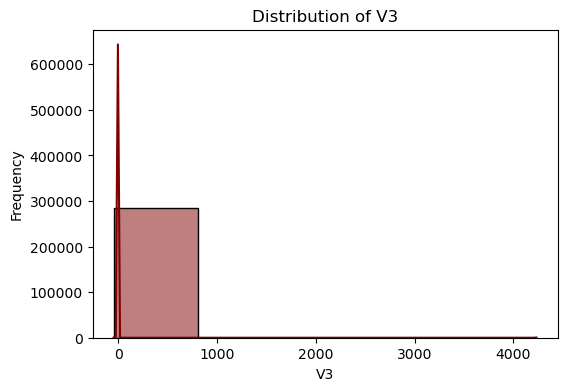

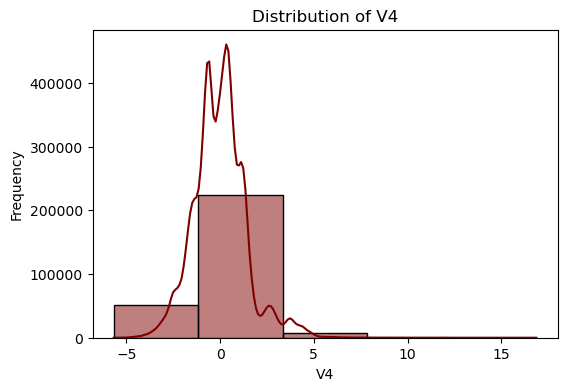

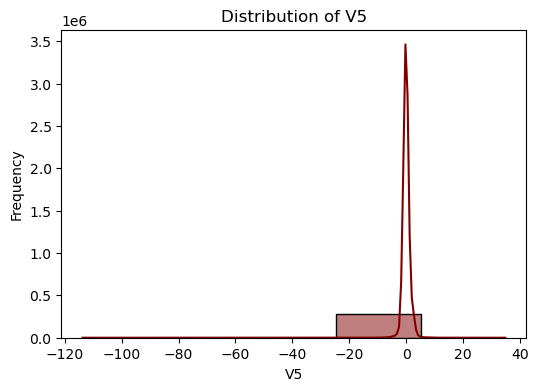

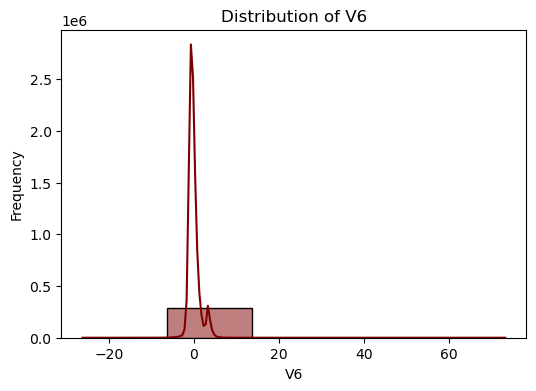

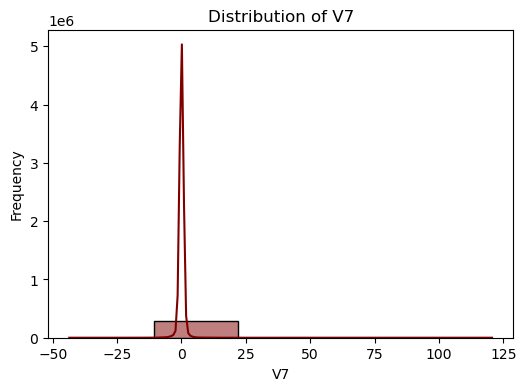

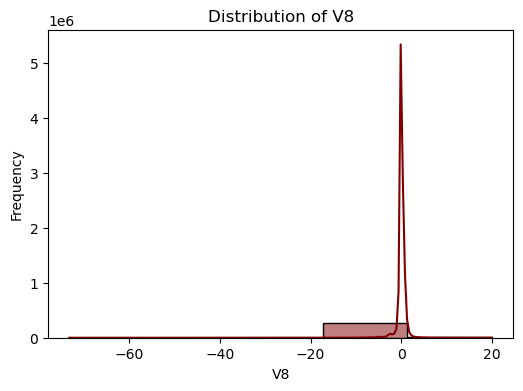

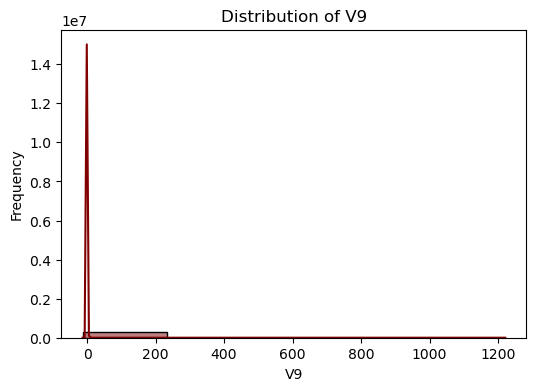

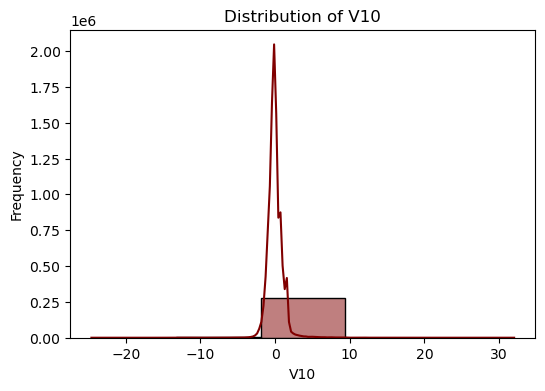

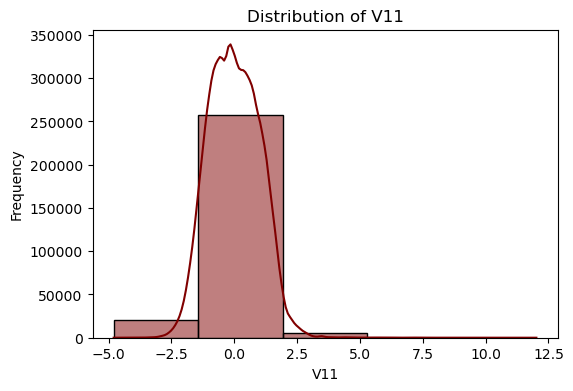

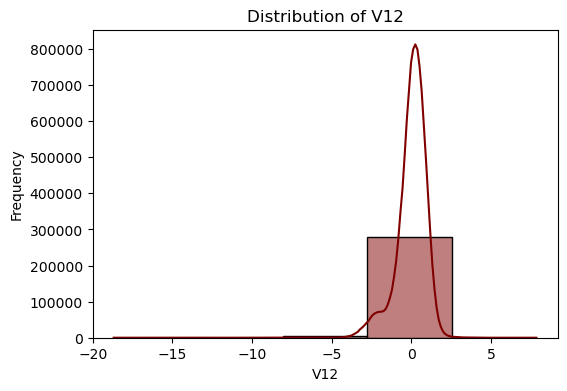

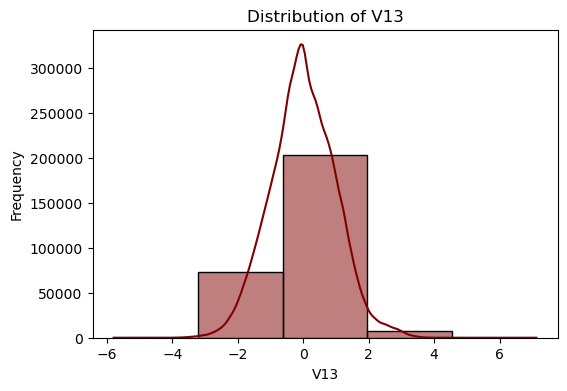

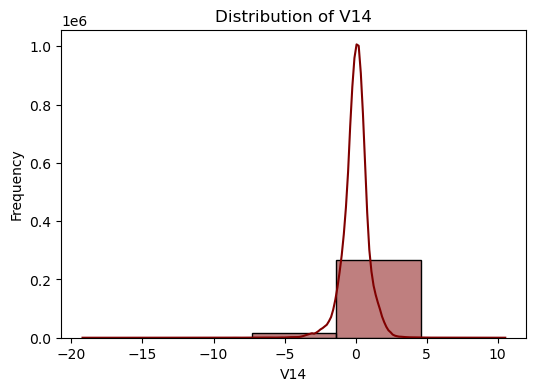

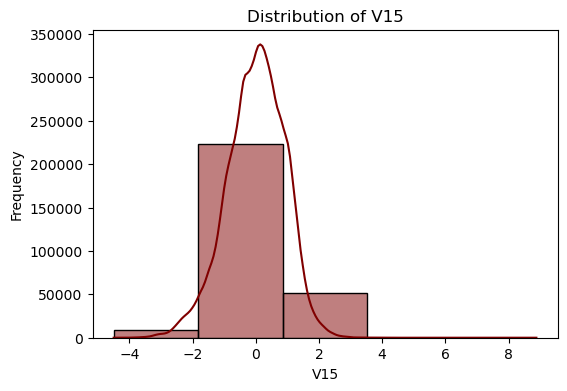

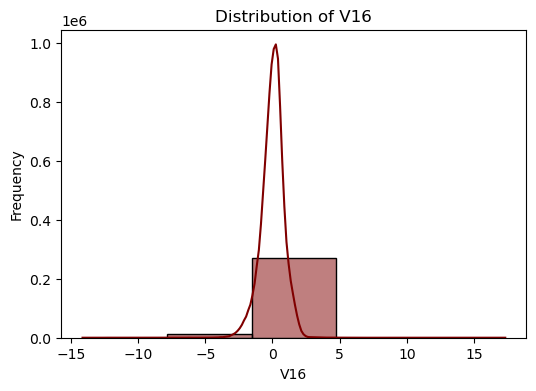

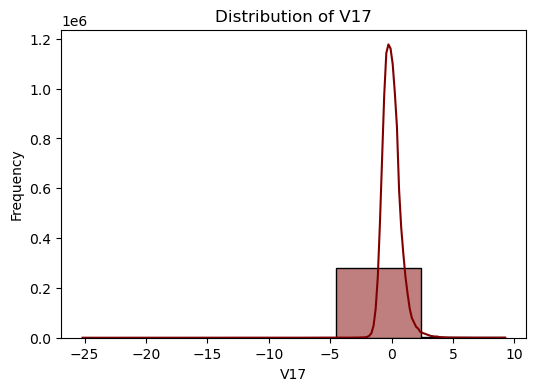

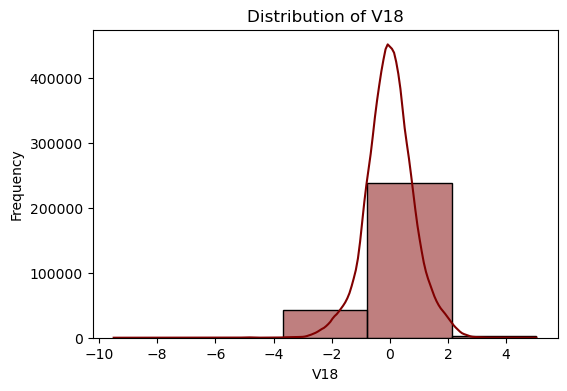

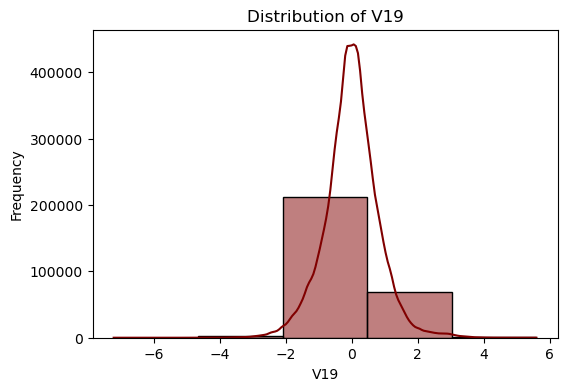

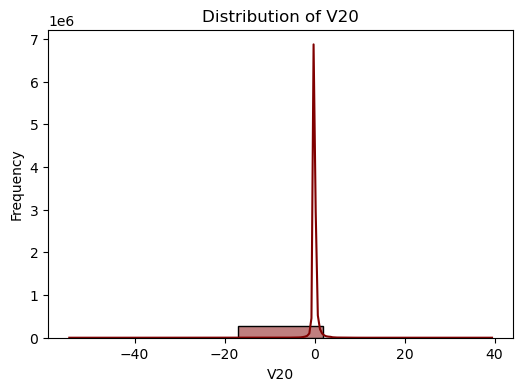

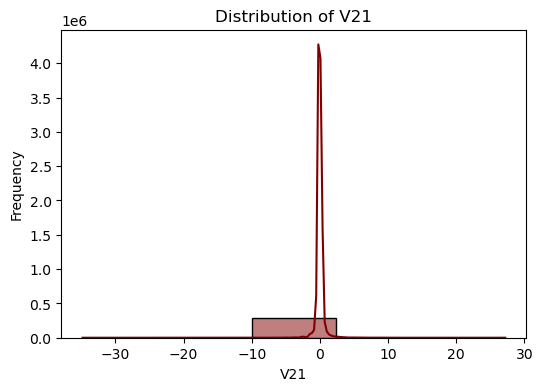

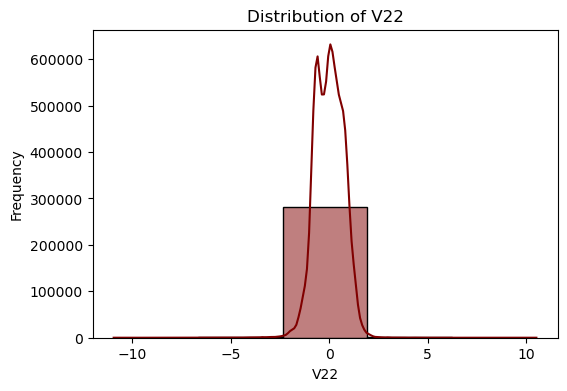

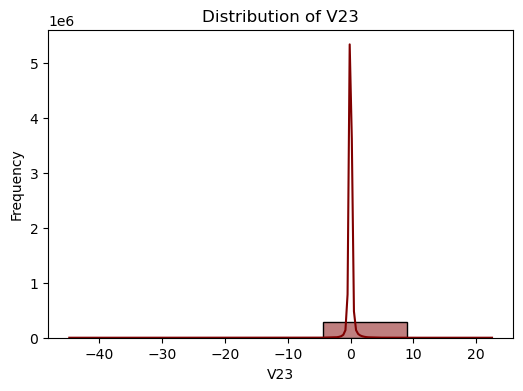

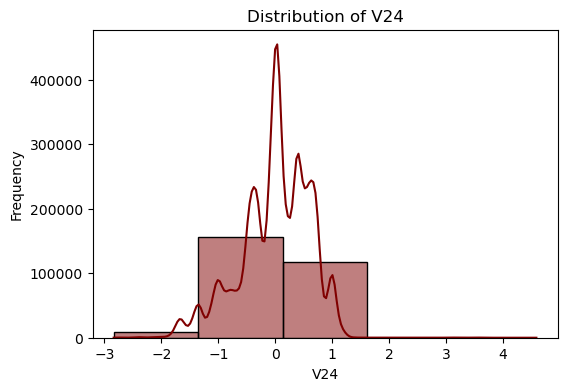

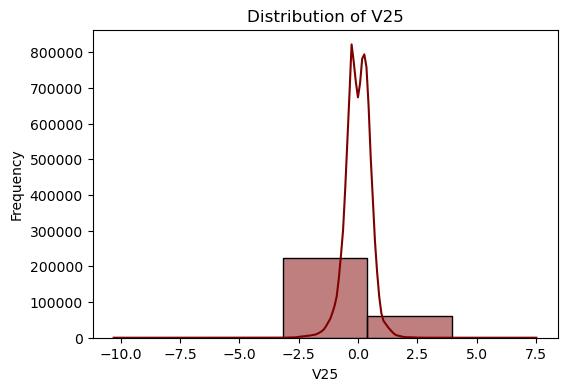

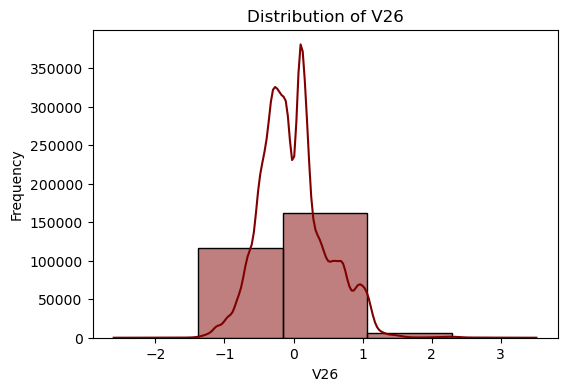

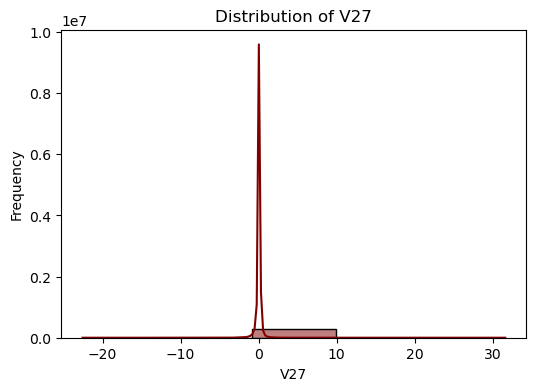

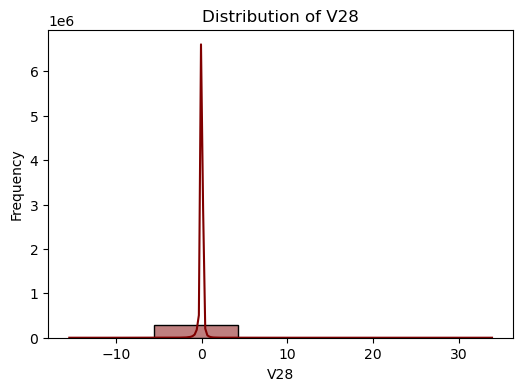

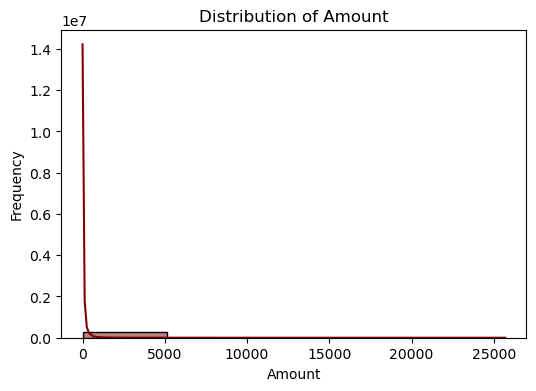

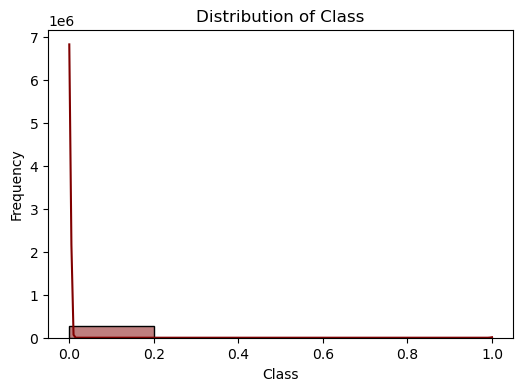

In [14]:
# Checking for the distribution of all the "numeric" columns in the dataset using histograms.
for col in ccfp.columns:
    plt.figure(figsize = (6, 4))
    sns.histplot(ccfp[col], kde = True, bins = 5, color = "maroon")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

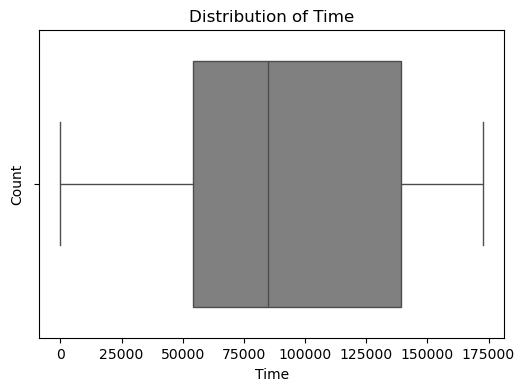

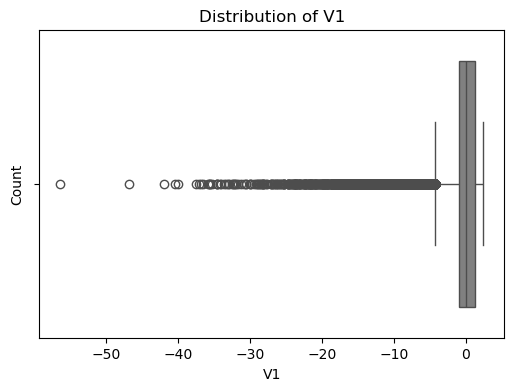

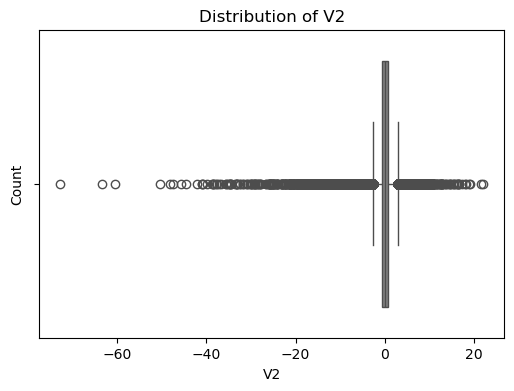

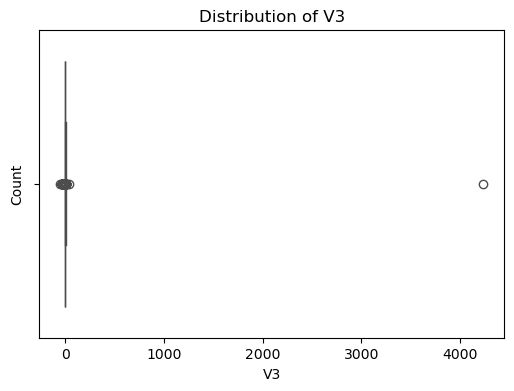

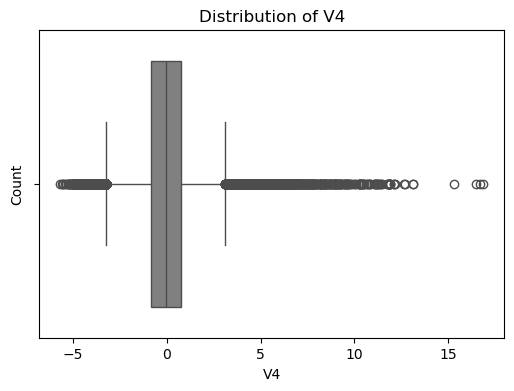

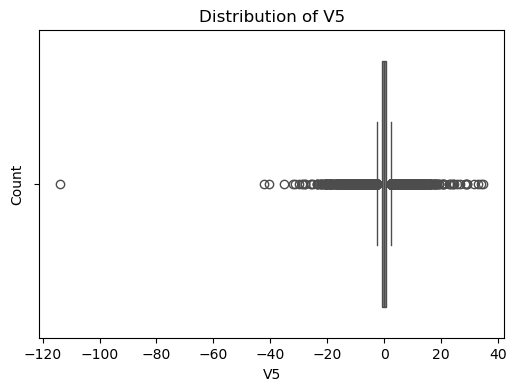

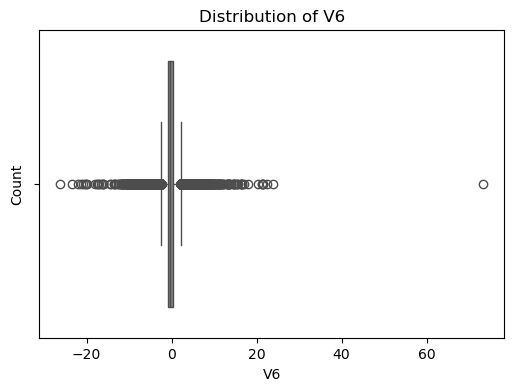

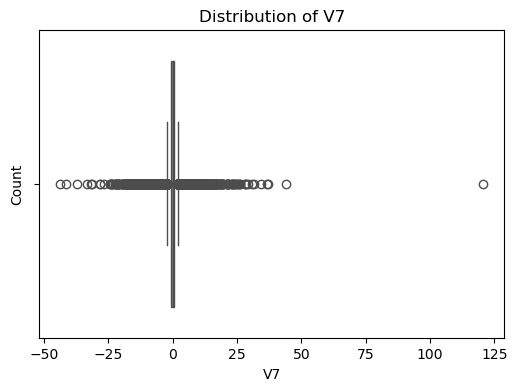

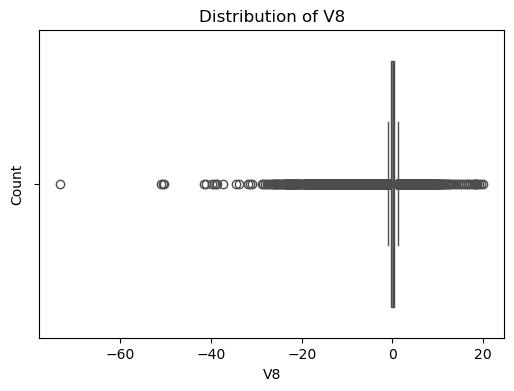

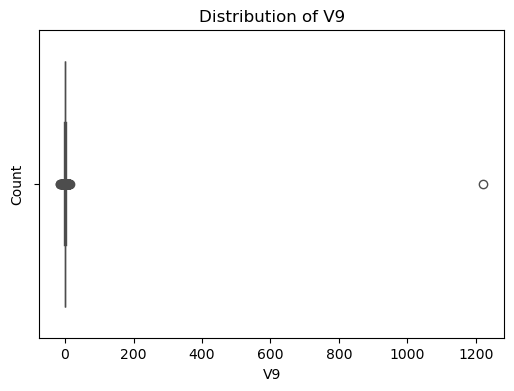

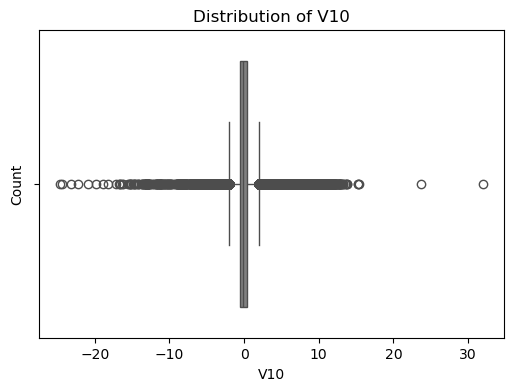

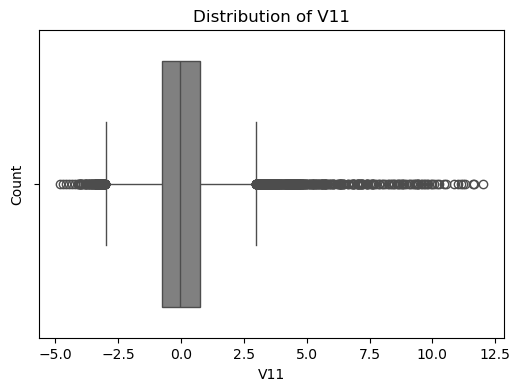

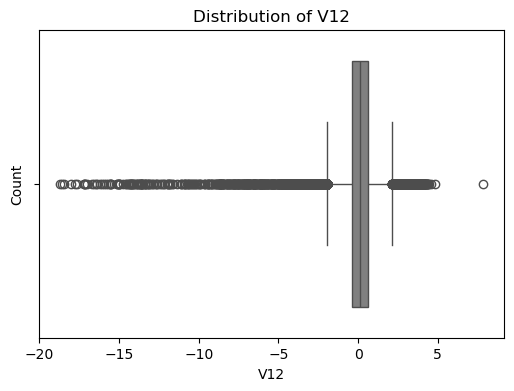

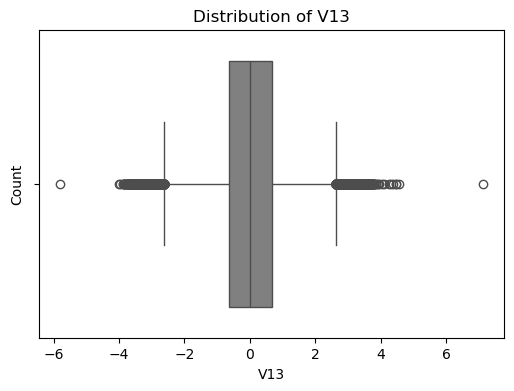

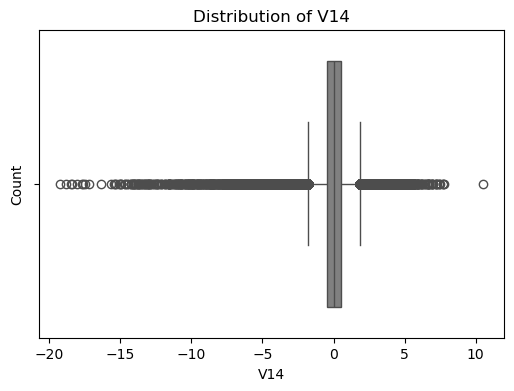

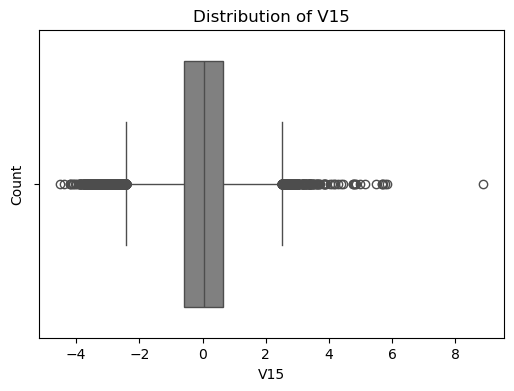

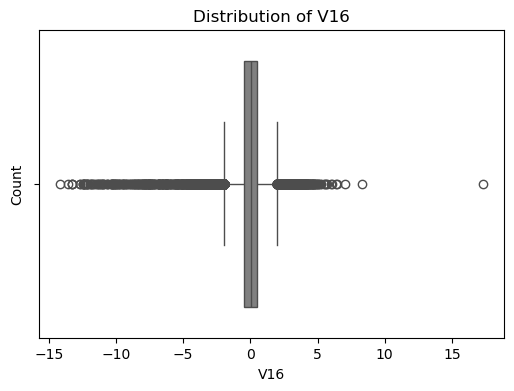

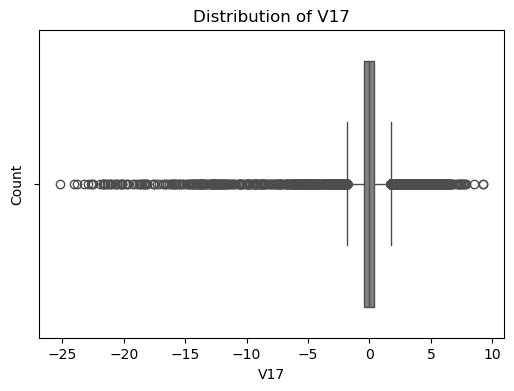

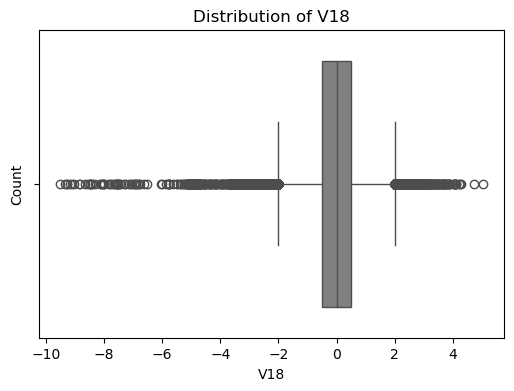

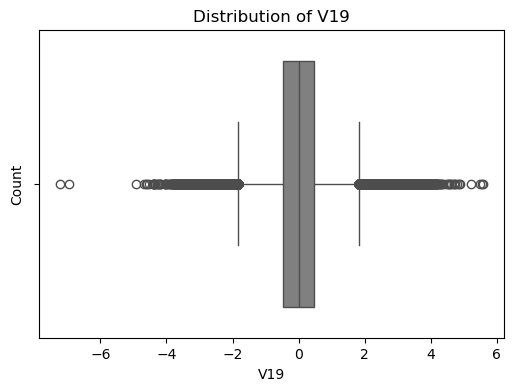

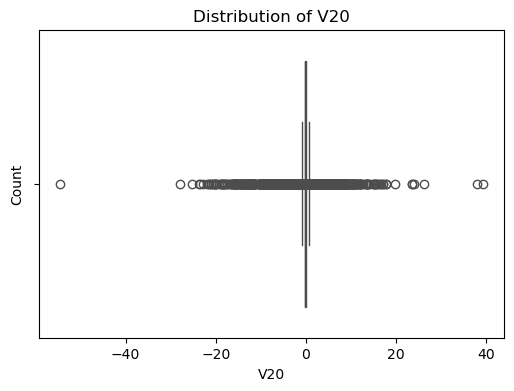

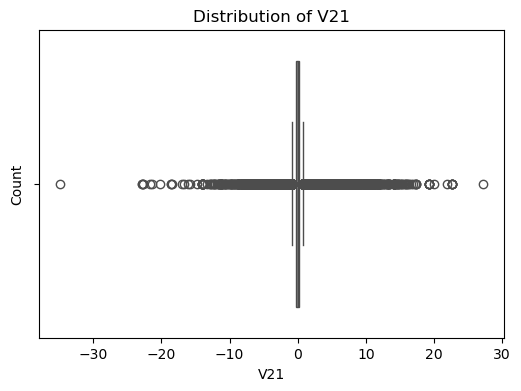

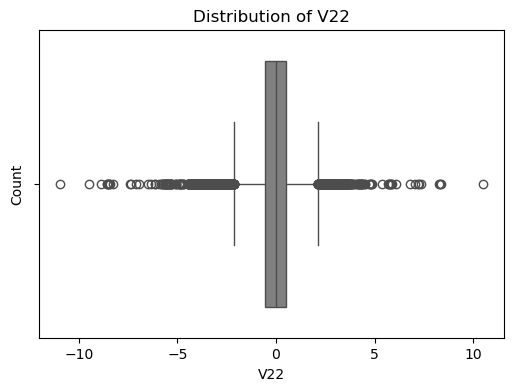

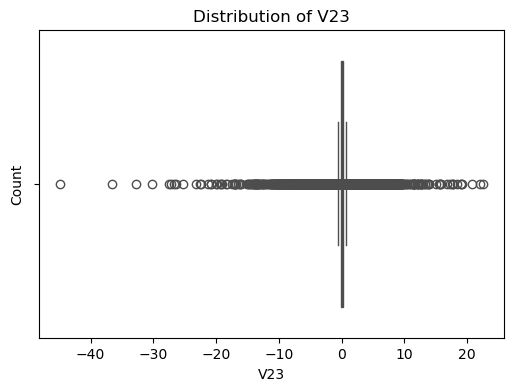

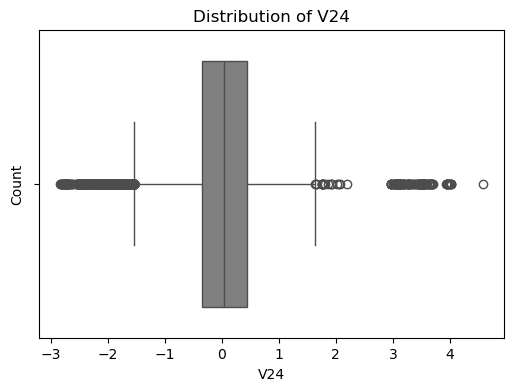

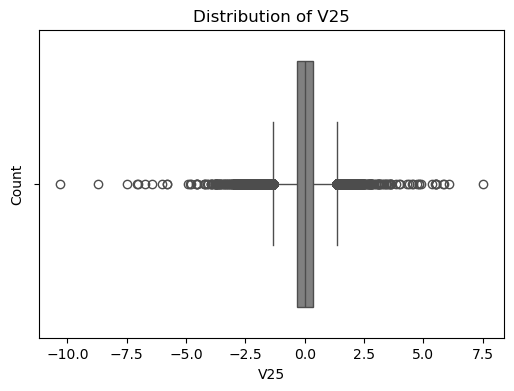

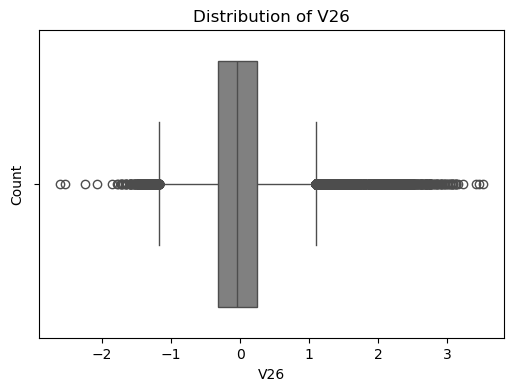

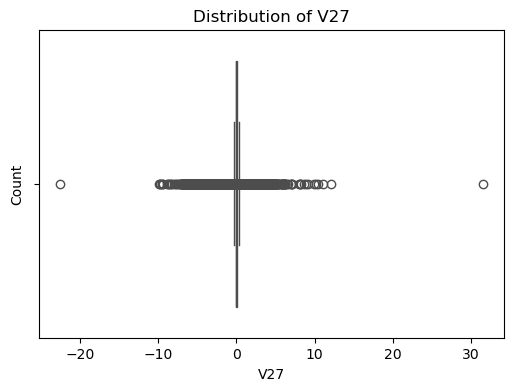

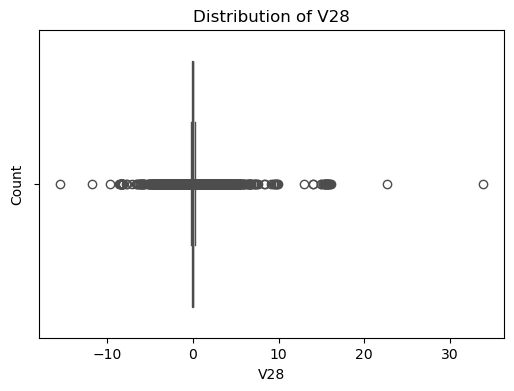

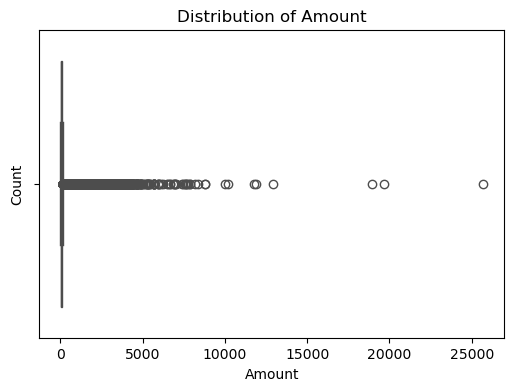

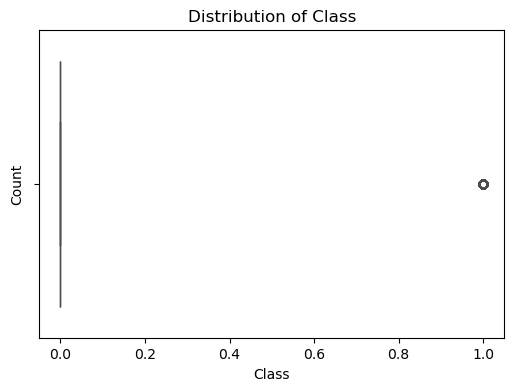

In [15]:
# Checking for the distribution of all the "numeric" columns in the dataset using boxplots.
for col in ccfp.columns:
    plt.figure(figsize = (6, 4))
    sns.boxplot(x = ccfp[col], showfliers = True, color = "grey")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

In [16]:
# Checking for the class imbalance in the target variable "Class".
ccfp["Class"].value_counts()

Class
0    283253
1       473
Name: count, dtype: int64

In [17]:
# Checking for the total outlier values in each column of the dataset using the IQR method.
for col in ccfp.columns:
    Q1 = ccfp[col].quantile(0.25)
    Q3 = ccfp[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = ccfp[(ccfp[col] < lower_bound) | (ccfp[col] > upper_bound)]
    print(f"Total outliers in {col}: {outliers.shape[0]}")

Total outliers in Time: 0
Total outliers in V1: 6949
Total outliers in V2: 13390
Total outliers in V3: 3307
Total outliers in V4: 11094
Total outliers in V5: 12221
Total outliers in V6: 22887
Total outliers in V7: 8838
Total outliers in V8: 23902
Total outliers in V9: 8199
Total outliers in V10: 9349
Total outliers in V11: 735
Total outliers in V12: 15283
Total outliers in V13: 3362
Total outliers in V14: 14060
Total outliers in V15: 2885
Total outliers in V16: 8180
Total outliers in V17: 7353
Total outliers in V18: 7468
Total outliers in V19: 10150
Total outliers in V20: 27553
Total outliers in V21: 14401
Total outliers in V22: 1298
Total outliers in V23: 18467
Total outliers in V24: 4758
Total outliers in V25: 5333
Total outliers in V26: 5665
Total outliers in V27: 38799
Total outliers in V28: 30094
Total outliers in Amount: 31685
Total outliers in Class: 473


In [18]:
# Using log transformation to reduce the skewness in the "Amount" column.
ccfp["Amount"] = np.log1p(ccfp["Amount"])

In [19]:
# Splitting the dataset into features and target variable.
X = ccfp.drop("Class", axis = 1)
X

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,5.014760
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,1.305626
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,5.939276
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,4.824306
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,4.262539
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,1.475829,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.570980
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.059616,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,3.249987
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.001396,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,4.232366
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.127434,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,2.397895


In [20]:
y = ccfp[["Class"]]
y

,Class
0,0
1,0
2,0
3,0
4,0
...,...
284802,0
284803,0
284804,0
284805,0


In [21]:
# Splitting the dataset into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((226980, 30), (56746, 30), (226980, 1), (56746, 1))

In [22]:
# Feature scaling.
# Creating an instance of StandardScaler. 
sc = StandardScaler()

In [23]:
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [24]:
# Handling class imbalance using SMOTE (Synthetic Minority Over-sampling Technique) only on the training dataset.
smote = SMOTE(random_state = 42)
X_train_scaled_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)
X_train_scaled_smote.shape, y_train_smote.shape

((453194, 30), (453194, 1))

In [25]:
# Checking for the class imbalance in the target variable "Class" after applying SMOTE.
y_train_smote["Class"].value_counts()

Class
0    226597
1    226597
Name: count, dtype: int64

In [26]:
# Building ML models. 
models = {
    "LR": LogisticRegression(class_weight = "balanced"),
    "DT": DecisionTreeClassifier(class_weight = "balanced"),
    "RF": RandomForestClassifier(class_weight = "balanced"),
    "GB": GradientBoostingClassifier(),
    "SVM": SVC(class_weight = "balanced"),
    "KNN": KNeighborsClassifier(),
    "NB": GaussianNB(),
    "XGB": xgb.XGBClassifier()
}

models

{'LR': LogisticRegression(class_weight='balanced'),
 'DT': DecisionTreeClassifier(class_weight='balanced'),
 'RF': RandomForestClassifier(class_weight='balanced'),
 'GB': GradientBoostingClassifier(),
 'SVM': SVC(class_weight='balanced'),
 'KNN': KNeighborsClassifier(),
 'NB': GaussianNB(),
 'XGB': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=None, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
               max_leaves=None, min_child_weight=None, missing=nan,
               monotone_constraints=None, multi_strategy=None, n_est

In [ ]:
# Training and evaluating the ML models.
for name, model in models.items():
    model.fit(X_train_scaled_smote, y_train_smote)
    y_pred = model.predict(X_test_scaled)

    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")
    print(f"Confusion Matrix for {name}:\n{confusion_matrix(y_test, y_pred)}")
    print(f"ROC AUC Score for {name}: {roc_auc_score(y_test, y_pred)}\n")
    print("-" * 50)

Classification Report for LR:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56656
           1       0.06      0.91      0.10        90

    accuracy                           0.98     56746
   macro avg       0.53      0.94      0.55     56746
weighted avg       1.00      0.98      0.99     56746

Confusion Matrix for LR:
[[55264  1392]
 [    8    82]]
ROC AUC Score for LR: 0.943270890206784

--------------------------------------------------
Classification Report for DT:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56656
           1       0.42      0.77      0.54        90

    accuracy                           1.00     56746
   macro avg       0.71      0.88      0.77     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix for DT:
[[56561    95]
 [   21    69]]
ROC AUC Score for DT: 0.8824949402240422

----------------------------------------

##### From the output above, we can infer that 

In [ ]:
# Saving the best performing model using joblib.
joblib.dump()

In [ ]:
# Saving the model columns. 
joblib.dump(X.columns, "Model_Columns.pkl")

In [ ]:
# Saving the Scaler. 
joblib.dump(sc, "Scaler.pkl")